# ❤️ Heart Failure Mortality Prediction

## Internship Project 1

### Objective
To predict whether a heart failure patient is likely to survive or not based on clinical records using Machine Learning and Deep Learning techniques.

Dataset Source:
https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data

## Step 1 : Importing Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Step 2 : Loading Dataset

In [15]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

## Step 3 : Dataset Preview

In [16]:
data_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Step 4 : Dataset Shape

In [17]:
data_df.shape


(299, 13)

### Observation

The dataset contains 299 rows and 13 columns.

## Step 5 : Dataset Information

In [18]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


## Step 6 : Checking Missing Values

In [19]:
data_df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

### Observation

No missing values are present in the dataset.

## Step 7 : Target Variable Analysis

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\1770640311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


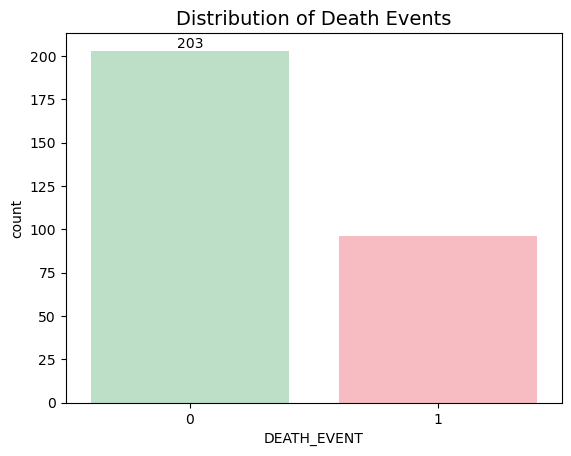

In [20]:
cols = ["#B8E3C5", "#FFB3BA"]

ax = sns.countplot(
    x=data_df["DEATH_EVENT"],
    palette=cols
)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Death Events", fontsize=14)
plt.show()

### Observation

There are more patients who survived compared to patients who died.
The dataset is slightly imbalanced.

## Step 8 : Correlation Analysis

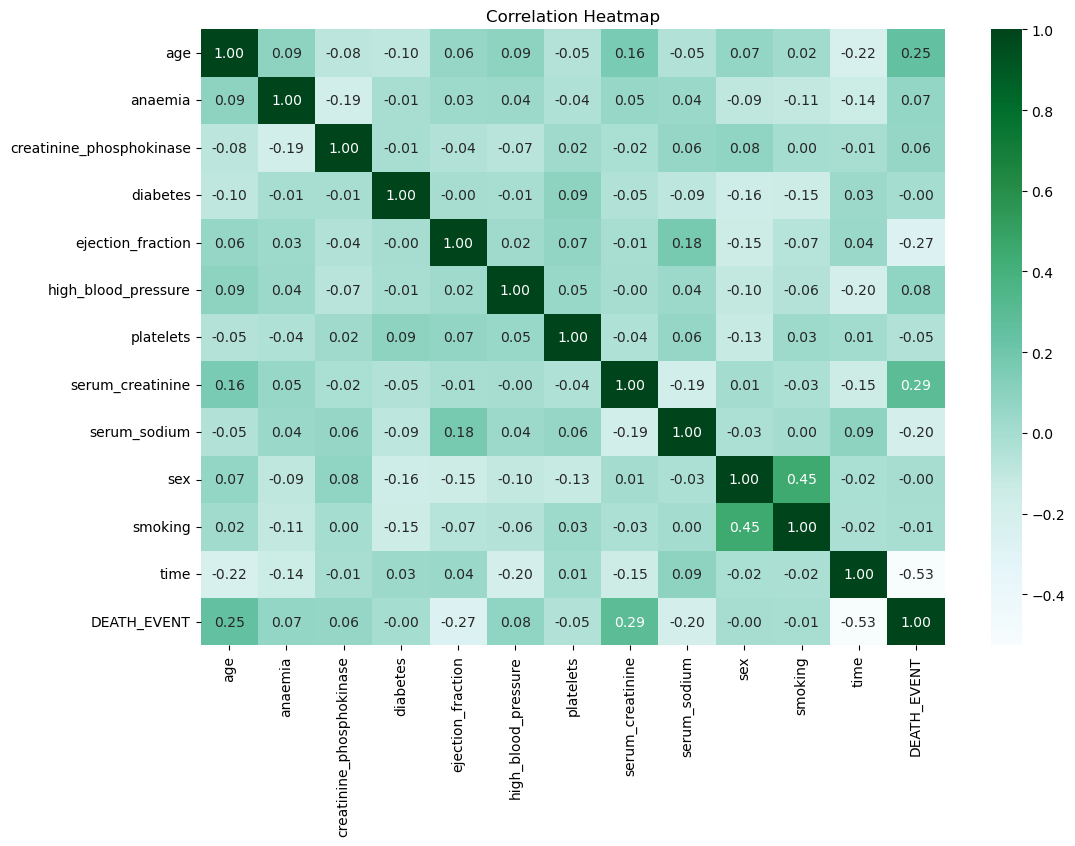

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data_df.corr(),
    annot=True,
    cmap="BuGn",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap helps identify relationships between clinical features and the target variable (DEATH_EVENT).

Features such as time, serum_creatinine and ejection_fraction show stronger relationships with mortality prediction.

In [25]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Step 9 : Feature Distribution Analysis

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


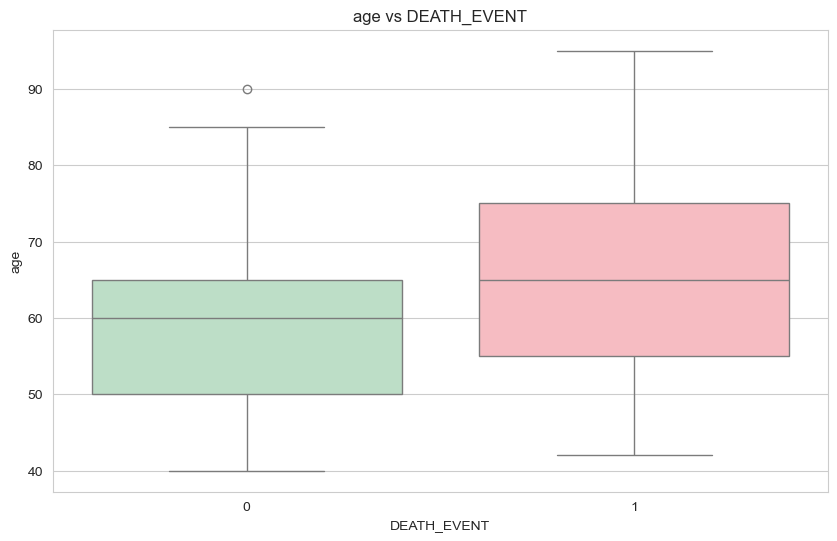

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


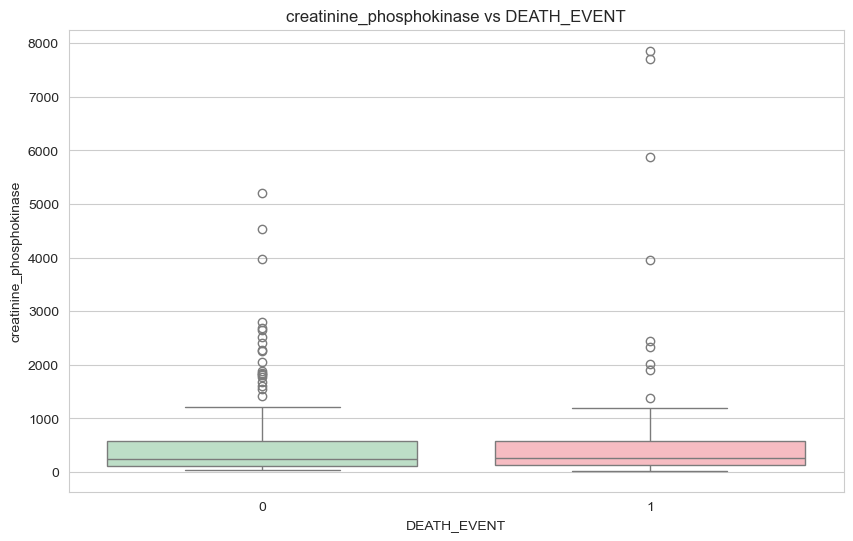

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


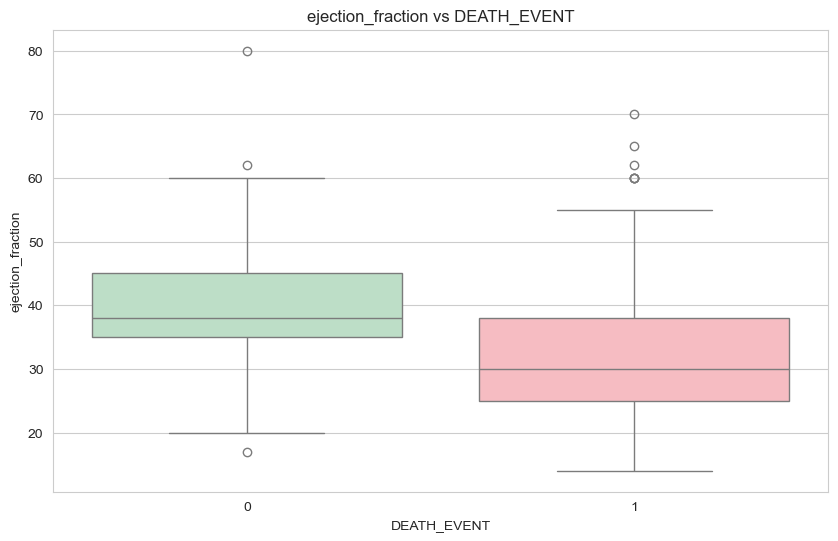

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


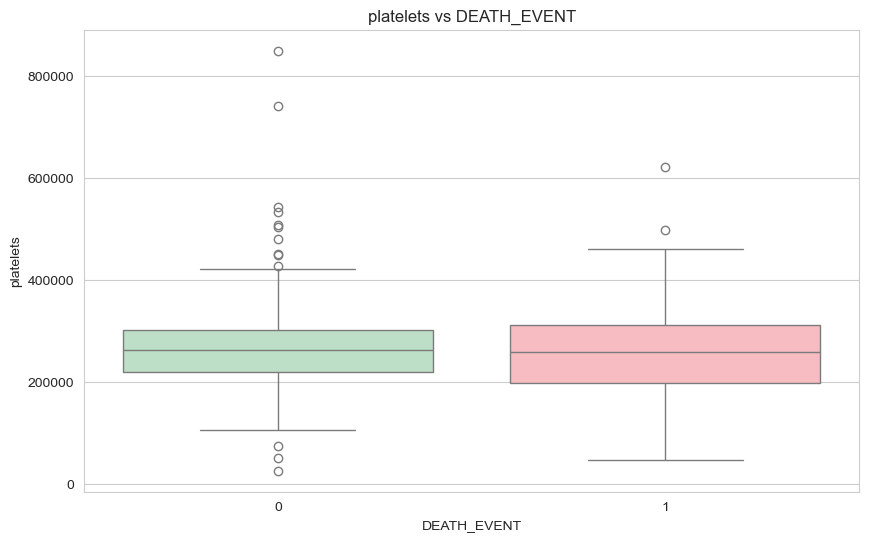

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


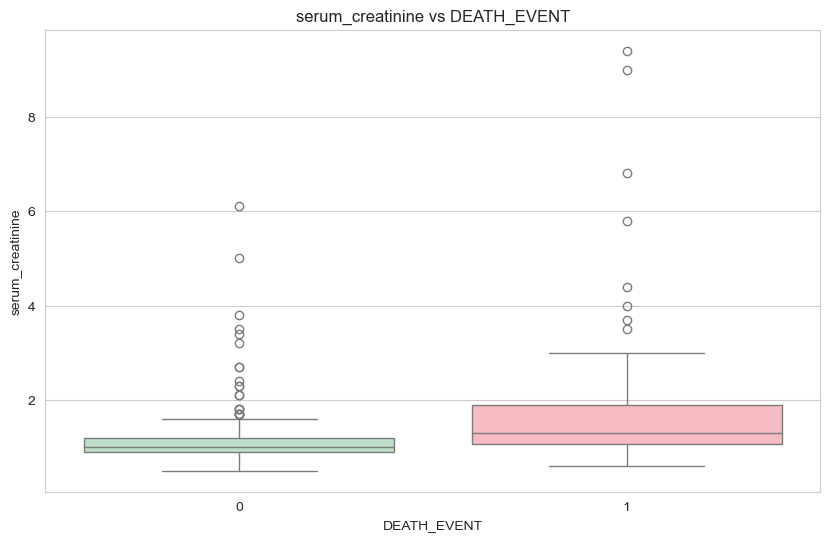

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


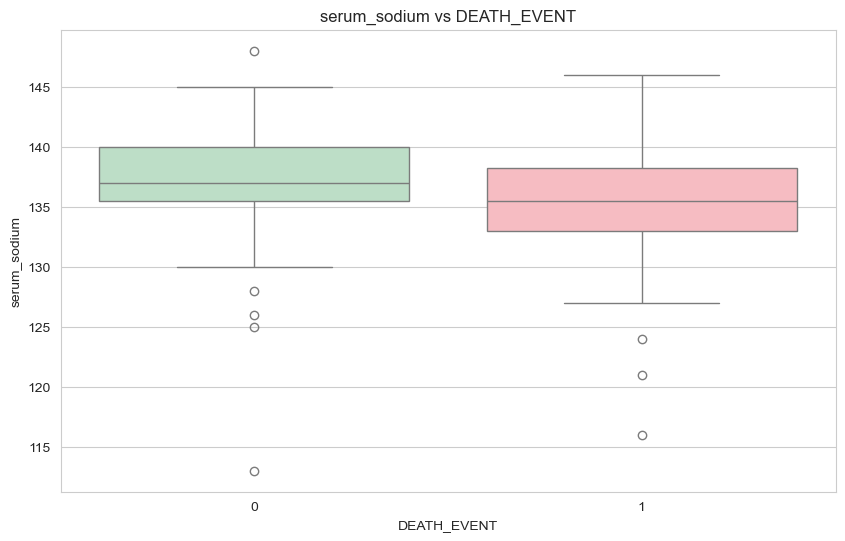

C:\Users\sridevi\AppData\Local\Temp\ipykernel_19360\3647777735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


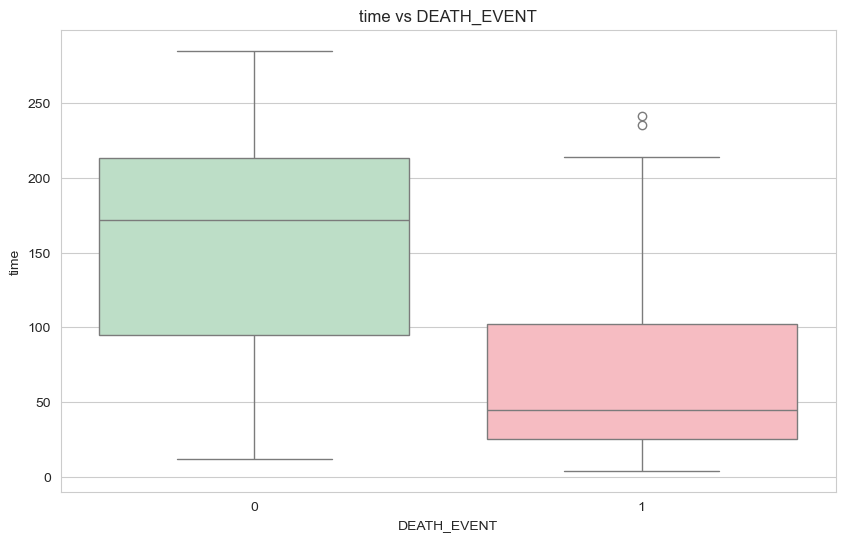

In [23]:
feature = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for f in feature:
    
    plt.figure(figsize=(10,6))
    
    sns.boxplot(
        x=data_df["DEATH_EVENT"],
        y=data_df[f],
        palette=["#B8E3C5","#FFB3BA"]
    )
    
    plt.title(f"{f} vs DEATH_EVENT")
    plt.show()

## Observation

The boxplots help compare feature distributions between survived and deceased patients.

Features such as age, serum_creatinine, ejection_fraction and time show noticeable differences between the two classes, making them important predictors.

## Step 10 : Data Preprocessing

In [26]:
data_df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

### Separating Features and Target Variable

In [27]:
X = data_df.drop("DEATH_EVENT", axis=1)

y = data_df["DEATH_EVENT"]

In [28]:
X.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


In [23]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: DEATH_EVENT, dtype: int64

## Step 11 : Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [31]:
X_scaled

array([[ 1.19294523e+00, -8.71104775e-01,  1.65728387e-04, ...,
         7.35688190e-01, -6.87681906e-01, -1.62950241e+00],
       [-4.91279276e-01, -8.71104775e-01,  7.51463953e+00, ...,
         7.35688190e-01, -6.87681906e-01, -1.60369074e+00],
       [ 3.50832977e-01, -8.71104775e-01, -4.49938761e-01, ...,
         7.35688190e-01,  1.45416070e+00, -1.59078490e+00],
       ...,
       [-1.33339153e+00, -8.71104775e-01,  1.52597865e+00, ...,
        -1.35927151e+00, -6.87681906e-01,  1.90669738e+00],
       [-1.33339153e+00, -8.71104775e-01,  1.89039811e+00, ...,
         7.35688190e-01,  1.45416070e+00,  1.93250906e+00],
       [-9.12335403e-01, -8.71104775e-01, -3.98321274e-01, ...,
         7.35688190e-01,  1.45416070e+00,  1.99703825e+00]],
      shape=(299, 12))

### Observation

Feature scaling standardizes the numerical values so that all features contribute equally during model training.

## Step 12 : Visualizing Scaled Features

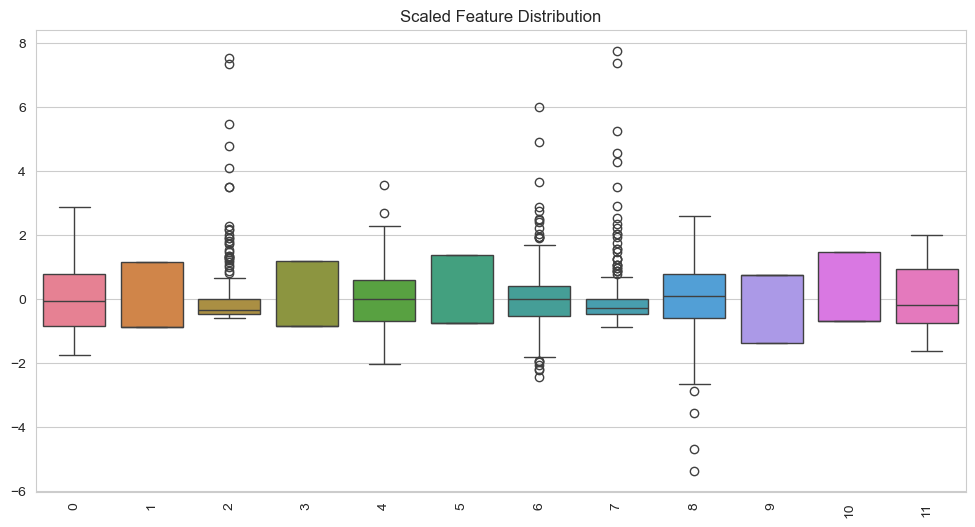

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(data=X_scaled)

plt.title("Scaled Feature Distribution")
plt.xticks(rotation=90)

plt.show()

### Observation

After scaling, the features are centered around a common range, reducing bias caused by different feature magnitudes.

## Step 13 : Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (239, 12)
X_test shape : (60, 12)
y_train shape : (239,)
y_test shape : (60,)


### Observation

The dataset has been split into training and testing sets.

80% of the data is used for training and 20% for testing.

## Step 14 : Building Deep Learning Model

In [35]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 2.7 MB/s eta 0:02:09
   ---------------------------------------- 1.0/351.2 MB 3.1 MB/s eta 0:01:54
   ---------------------------------------- 1.8/351.2 MB 3.4 MB/s eta 0:01:45
   ---------------------------------------- 2.9/351.2 MB 3.7 MB/s eta 0:01:36
   ---------------------------------------- 3.9/351.2 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 4.5/351.2 MB 4.0 MB/s eta 0:01:28
    --------------------------------------- 4.5/351.2 MB 4.0 MB/s eta 0:01:28
    --------------------------------------- 5.2/351.2 MB 3.1 MB/s eta 0:01:50
    --------------------------------------- 6.3/351.2 MB 3.3 MB/s eta 0:01:43
    --------------------------------------- 7.3/351.2 MB 3.5 MB/s eta 0:01:38
    --------------------------------------- 8.1/351.2 MB 3.5 MB/s eta 0:01:38
   - -------------------------------------- 8.9/351.2 MB 3.5 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


# Step 15 : Import Deep Learning Libraries

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Step 16 : Building Neural Network Architecture

In [37]:
model = Sequential()

model.add(Dense(units=16,
                kernel_initializer='uniform',
                activation='relu',
                input_dim=12))

model.add(Dense(units=8,
                kernel_initializer='uniform',
                activation='relu'))

model.add(Dropout(0.25))

model.add(Dense(units=8,
                kernel_initializer='uniform',
                activation='relu'))

model.add(Dropout(0.25))

model.add(Dense(units=1,
                kernel_initializer='uniform',
                activation='sigmoid'))

C:\Users\sridevi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 17 : Model Summary

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

# Step 18 : Compiling the Neural Network

In [39]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 19 : Training the Model

In [40]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.6440 - loss: 0.6926 - val_accuracy: 0.7500 - val_loss: 0.6916
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6911 - loss: 0.6914 - val_accuracy: 0.7500 - val_loss: 0.6900
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6911 - loss: 0.6904 - val_accuracy: 0.7500 - val_loss: 0.6884
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6911 - loss: 0.6889 - val_accuracy: 0.7500 - val_loss: 0.6869
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6911 - loss: 0.6877 - val_accuracy: 0.7500 - val_loss: 0.6853
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6911 - loss: 0.6865 - val_accuracy: 0.7500 - val_loss: 0.6835
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6911 - loss: 0.6851 - val_accuracy: 0.7500 - val_loss: 0.6817
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6911 - loss: 0.6835 - val_accuracy: 0.7500 - val_loss:

# Step 20 : Visualizing Accuracy Curve

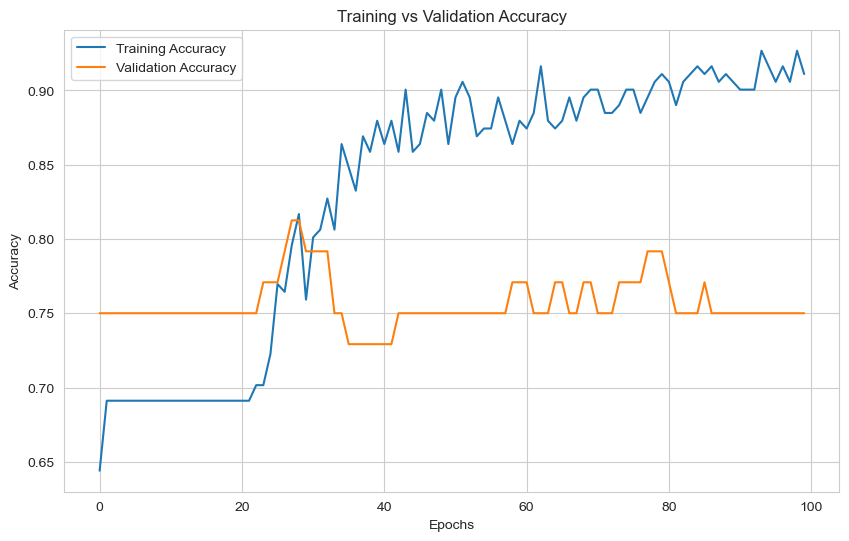

In [41]:
plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Observation

The training accuracy increases steadily with epochs, showing that the neural network is learning patterns from the dataset.

The validation accuracy remains around 75%, indicating stable performance on unseen data and acceptable generalization capability.

# Step 21 : Visualizing Loss Curve

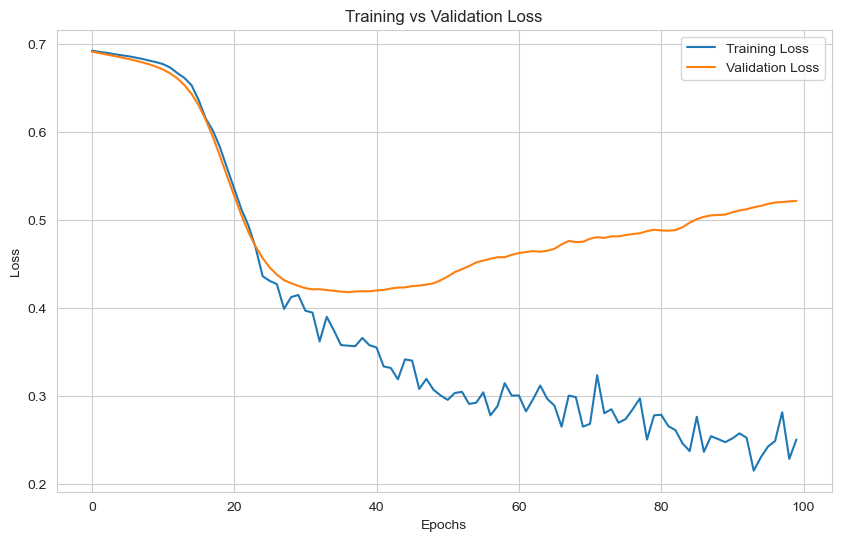

In [42]:
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Observation

The training loss decreases continuously throughout the training process, indicating effective learning by the neural network.

The validation loss decreases initially and then gradually increases after approximately 30 epochs, suggesting slight overfitting. However, the validation accuracy remains stable around 75%, indicating acceptable model performance.

# Step 22 : Evaluating the Model

In [43]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7500 - loss: 0.8510
Test Loss : 0.8509543538093567
Test Accuracy : 0.75


### Observation

The trained neural network achieves satisfactory accuracy on the testing dataset.

This indicates that the model can generalize reasonably well to unseen patient records.

In [44]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7500 - loss: 0.8510


[0.8509543538093567, 0.75]

# Step 23 : Making Predictions|

In [45]:
predictions = model.predict(X_test)

predictions[:10]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[8.3140038e-02],
       [7.5107841e-05],
       [1.0004066e-01],
       [9.3667561e-01],
       [5.3703138e-03],
       [2.4668048e-03],
       [8.0269271e-01],
       [4.9817406e-02],
       [9.0235609e-01],
       [2.2486260e-03]], dtype=float32)

In [46]:
predicted_classes = (predictions > 0.5).astype(int)

predicted_classes[:10]

array([[0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0]])

### Observation

The model generates probability scores between 0 and 1.

Values greater than 0.5 are classified as death events, while values less than 0.5 are classified as survival cases.

# Step 24 : Conclusion

A Deep Learning model was developed using TensorFlow and Keras to predict heart failure outcomes based on clinical records.

The dataset was preprocessed through feature scaling and train-test splitting before model training.

The neural network achieved approximately 75% testing accuracy, demonstrating its capability to identify patterns associated with patient survival and mortality.

This project highlights the application of Deep Learning techniques in healthcare prediction systems and clinical decision support.

# Project Outcome

✅ Dataset Loaded Successfully

✅ Exploratory Data Analysis Performed

✅ Missing Values Checked

✅ Correlation Analysis Completed

✅ Feature Scaling Applied

✅ Deep Learning Model Built

✅ Model Trained Successfully

✅ Testing Accuracy Achieved: 75%

✅ Heart Failure Prediction Completed

# Final Result

The Deep Learning model was successfully trained using TensorFlow and Keras.

The model achieved:

- Training Accuracy: 91.10%
- Validation Accuracy: 75.00%
- Test Accuracy: 75.00%

The model is capable of predicting heart failure outcomes based on clinical patient records and demonstrates the practical application of Deep Learning in healthcare analytics.